In [235]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim

In [236]:
data = pd.read_csv('./data/train_data.csv')

data = data.drop(['ID', 'Name'], axis=1)
data = data[data['Year Published'].notna()]
Y = data['Rating Average']
data = data.drop(['Rating Average'], axis=1)

In [237]:
test = pd.read_csv('./data/test_data.csv')
test = test.drop(['ID', 'Name'], axis=1)

In [238]:
Y = Y.str.replace(',', '.').astype(float)
Y.dtype

dtype('float64')

In [239]:
data.isna().sum()

Year Published           0
Min Players              0
Max Players              0
Play Time                0
Min Age                  0
Users Rated              0
BGG Rank                 0
Complexity Average       0
Owned Users             16
Mechanics             1199
Domains               7648
dtype: int64

In [240]:
data.dtypes

Year Published        float64
Min Players             int64
Max Players             int64
Play Time               int64
Min Age                 int64
Users Rated             int64
BGG Rank                int64
Complexity Average     object
Owned Users           float64
Mechanics              object
Domains                object
dtype: object

In [241]:
data['Complexity Average'] = data['Complexity Average'].str.replace(',', '.').astype(float)
test['Complexity Average'] = test['Complexity Average'].str.replace(',', '.').astype(float)

In [242]:
def create_boxplot(arg):
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=data[arg].dropna())
    plt.title(arg)
    plt.grid(True, alpha=0.3)
    plt.show()

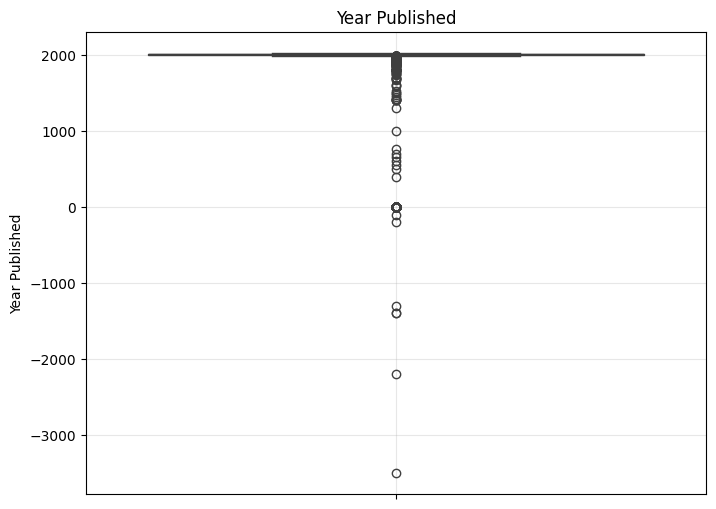

In [243]:
create_boxplot('Year Published')

In [244]:
# создадим признак - неизвестный год
data['Year Unknown'] = (data['Year Published'] < 1700).astype(float)
test['Year Unknown'] = (test['Year Published'] < 1700).astype(float)


In [245]:
# заполним медианой Year Published
median_positive = data.loc[data['Year Published'] > 0, 'Year Published'].median()
data.loc[data['Year Published'] <= 0, 'Year Published'] = median_positive
test.loc[data['Year Published'] <= 0, 'Year Published'] = median_positive

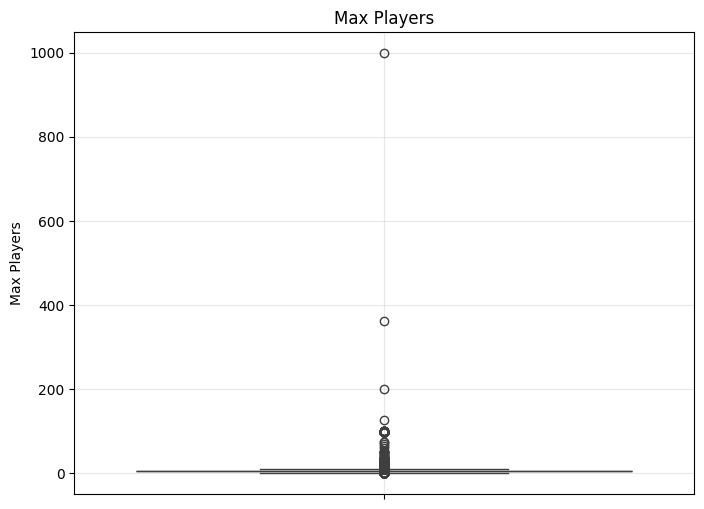

In [246]:
# у Min Players ничего интересного
create_boxplot('Max Players')

In [247]:
# сделаем, чтобы максимальное число игроков было 20
data['Max Players'] = data['Max Players'].clip(upper=20)
test['Max Players'] = test['Max Players'].clip(upper=20)

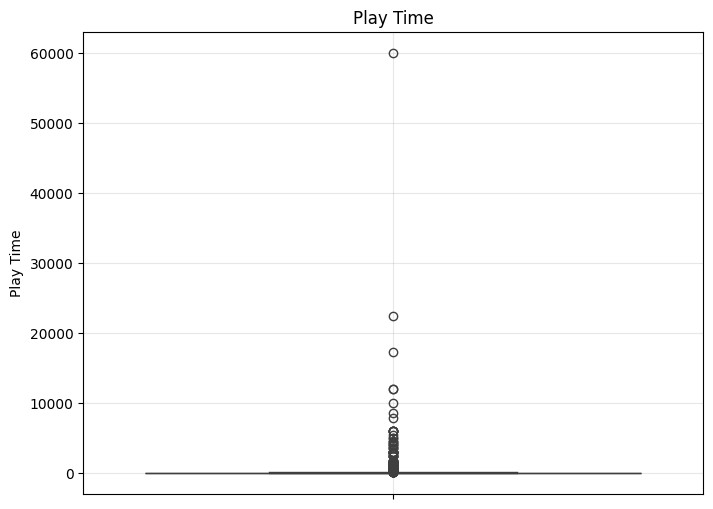

In [248]:
create_boxplot('Play Time')

In [249]:
data['Play Time'] = data['Play Time'].clip(upper=200)
test['Play Time'] = test['Play Time'].clip(upper=200)

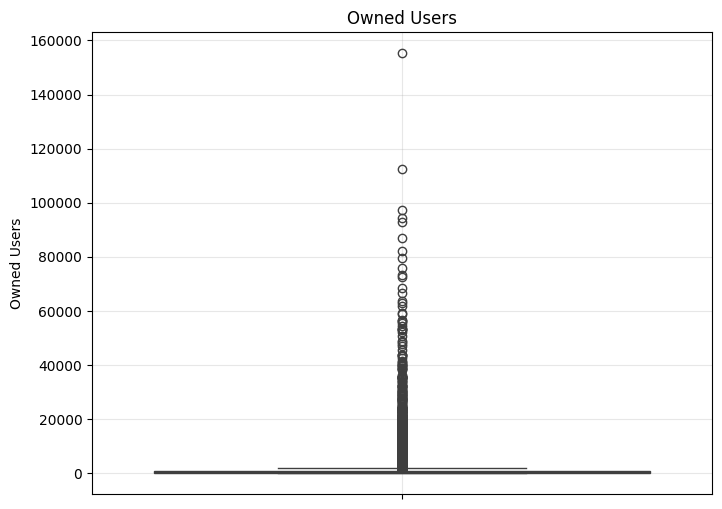

In [250]:
create_boxplot('Owned Users')

In [251]:
data['Owned Users'] = data['Owned Users'].clip(upper=40000)
data['Owned Users'] = data['Owned Users'].fillna(0)

test['Owned Users'] = test['Owned Users'].clip(upper=40000)
test['Owned Users'] = test['Owned Users'].fillna(0)

In [252]:
data['No Min Players'] = (data['Min Players'] == 0).astype(float)
data['No Max Players'] = (data['Max Players'] == 0).astype(float)
data['No Play Time'] = (data['Play Time'] == 0).astype(float)
data['No Min Age'] = (data['Min Age'] == 0).astype(float)

test['No Min Players'] = (test['Min Players'] == 0).astype(float)
test['No Max Players'] = (test['Max Players'] == 0).astype(float)
test['No Play Time'] = (test['Play Time'] == 0).astype(float)
test['No Min Age'] = (test['Min Age'] == 0).astype(float)

In [253]:
data['No Mechanics'] = data['Mechanics'].isna().astype(float)
data['No Domains'] = data['Domains'].isna().astype(float)

test['No Mechanics'] = test['Mechanics'].isna().astype(float)
test['No Domains'] = test['Domains'].isna().astype(float)

In [254]:
mechanics_dummies = data['Mechanics'].str.get_dummies(sep=', ')
counts = mechanics_dummies.sum()

frequent_cols = counts[counts > 750].index
rare_cols = counts[counts <= 750].index

if len(rare_cols) > 0:
    data['rare_mechanics'] = mechanics_dummies[rare_cols].any(axis=1).astype(int)
else:
    data['rare_mechanics'] = 0

data = pd.concat([data, mechanics_dummies[frequent_cols]], axis=1)

data = data.drop('Mechanics', axis=1)

In [255]:
test_mechanics_dummies = test['Mechanics'].str.get_dummies(sep=', ')

cols_to_check_rare = test_mechanics_dummies.columns.difference(frequent_cols)

if len(cols_to_check_rare) > 0:
    test['rare_mechanics'] = test_mechanics_dummies[cols_to_check_rare].any(axis=1).astype(int)
else:
    test['rare_mechanics'] = 0

test_frequent = test_mechanics_dummies.reindex(columns=frequent_cols, fill_value=0)

test = pd.concat([test, test_frequent], axis=1)
test = test.drop('Mechanics', axis=1)

In [256]:
domains_dummies = data['Domains'].str.get_dummies(sep=', ')
counts = domains_dummies.sum()

frequent_cols = counts[counts > 250].index
rare_cols = counts[counts <= 250].index

if len(rare_cols) > 0:
    data['rare_domains'] = domains_dummies[rare_cols].any(axis=1).astype(int)
else:
    data['rare_domains'] = 0

data = pd.concat([data, domains_dummies[frequent_cols]], axis=1)

data = data.drop('Domains', axis=1)

In [257]:
test_domains_dummies = test['Domains'].str.get_dummies(sep=', ')

cols_to_check_rare = test_domains_dummies.columns.difference(frequent_cols)

if len(cols_to_check_rare) > 0:
    test['rare_domains'] = test_domains_dummies[cols_to_check_rare].any(axis=1).astype(int)
else:
    test['rare_domains'] = 0

test_frequent = test_domains_dummies.reindex(columns=frequent_cols, fill_value=0)

test = pd.concat([test, test_frequent], axis=1)
test = test.drop('Domains', axis=1)

In [258]:
print(len(data.columns))
print(len(test.columns))

43
43


In [259]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
data = pd.DataFrame(data_scaled, columns=data.columns, index=data.index)

test_scaled = scaler.transform(test)
test = pd.DataFrame(test_scaled, columns=test.columns, index=test.index)

In [260]:
class RegressionNet(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

In [261]:
input_dim = data.shape[1]
model = RegressionNet(input_dim)

criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5000
batch_size = 32

In [262]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    data, Y,
    test_size=0.2,
    random_state=42
)

In [263]:
from torch.utils.data import DataLoader, TensorDataset

X_train = torch.tensor(X_train.to_numpy(), dtype=torch.float32)
y_train = torch.tensor(y_train.to_numpy(), dtype=torch.float32).view(-1, 1)

X_val = torch.tensor(X_val.to_numpy(), dtype=torch.float32)
y_val = torch.tensor(y_val.to_numpy(), dtype=torch.float32).view(-1, 1)

torch.set_grad_enabled(True)

for epoch in range(num_epochs):
    model.train()
    
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    # validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: train_loss={loss.item():.4f}, val_loss={val_loss.item():.4f}")



Epoch 0: train_loss=41.4655, val_loss=42.1212
Epoch 100: train_loss=0.7705, val_loss=0.3596
Epoch 200: train_loss=0.6188, val_loss=0.2448
Epoch 300: train_loss=0.5446, val_loss=0.2251
Epoch 400: train_loss=0.5156, val_loss=0.2138
Epoch 500: train_loss=0.4730, val_loss=0.2026
Epoch 600: train_loss=0.4429, val_loss=0.1919
Epoch 700: train_loss=0.4154, val_loss=0.1823
Epoch 800: train_loss=0.3955, val_loss=0.1715
Epoch 900: train_loss=0.3671, val_loss=0.1617
Epoch 1000: train_loss=0.3556, val_loss=0.1541
Epoch 1100: train_loss=0.3328, val_loss=0.1422
Epoch 1200: train_loss=0.3062, val_loss=0.1339
Epoch 1300: train_loss=0.2899, val_loss=0.1264
Epoch 1400: train_loss=0.2746, val_loss=0.1228
Epoch 1500: train_loss=0.2406, val_loss=0.1193
Epoch 1600: train_loss=0.2207, val_loss=0.1154
Epoch 1700: train_loss=0.1910, val_loss=0.1142
Epoch 1800: train_loss=0.1609, val_loss=0.1119
Epoch 1900: train_loss=0.1390, val_loss=0.1176
Epoch 2000: train_loss=0.1282, val_loss=0.1102
Epoch 2100: train_loss=

In [264]:
import numpy as np

X_test_tensor = torch.tensor(test.values, dtype=torch.float32)
test_dataset = TensorDataset(X_test_tensor)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model.eval()
predictions = []

with torch.no_grad():
    for (X_batch,) in test_dataloader:
        outputs = model(X_batch)
        predictions.extend(outputs.cpu().numpy())

predictions = np.array(predictions).flatten()

submission = pd.DataFrame({
    'index': range(len(predictions)),
    'Rating Average': predictions
})

submission.to_csv('./submission.csv', index=False)